In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trader_data = pd.read_csv("historical_data.csv")
sentiment_data = pd.read_csv("fear_greed_index.csv")

In [5]:
trader_data.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trader_data['Timestamp IST'] = pd.to_datetime(trader_data['Timestamp IST'], format="%d-%m-%Y %H:%M")
trader_data['Date'] = trader_data['Timestamp IST'].dt.date
trader_data['Date'] = pd.to_datetime(trader_data['Date'])

sentiment_data['date'] = pd.to_datetime(sentiment_data['date'])
sentiment_data.rename(columns={'date':'Date'}, inplace=True)

In [9]:
merged = pd.merge(trader_data, sentiment_data[['Date','classification','value']], on="Date", how="inner")

In [11]:
performance = merged.groupby('classification')['Closed PnL'].mean().reset_index()
print(performance.head())


  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


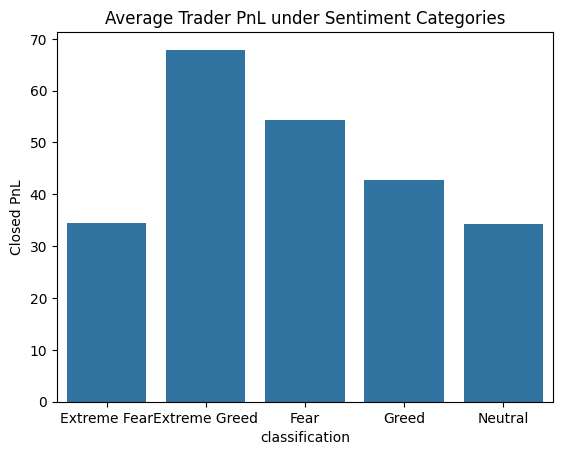

In [12]:
sns.barplot(x='classification', y='Closed PnL', data=performance)
plt.title("Average Trader PnL under Sentiment Categories")
plt.show()


In [13]:
if 'leverage' in merged.columns:
    sns.boxplot(x='classification', y='leverage', data=merged)
    plt.title("Leverage Distribution under Sentiment Categories")
    plt.show()

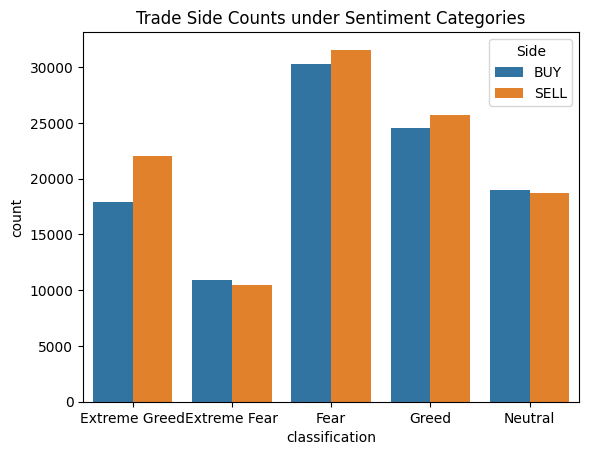

In [14]:
sns.countplot(x='classification', hue='Side', data=merged)
plt.title("Trade Side Counts under Sentiment Categories")
plt.show()


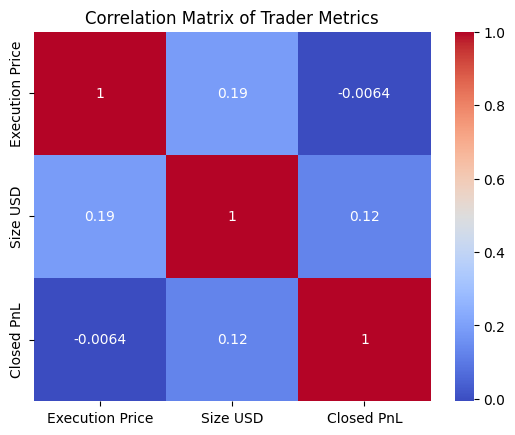

In [15]:
corr = merged[['Execution Price','Size USD','Closed PnL']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Trader Metrics")
plt.show()


In [16]:
summary_stats = merged[['Execution Price','Size USD','Closed PnL']].groupby(merged['classification']).describe()
print(summary_stats)


               Execution Price                                        \
                         count          mean           std       min   
classification                                                         
Extreme Fear           21400.0   7054.795108  22281.739294  0.000269   
Extreme Greed          39992.0   6082.195865  23201.177889  0.000005   
Fear                   61837.0  14152.620222  31644.432937  0.000010   
Greed                  50303.0  13411.276344  31515.317080  0.000017   
Neutral                37686.0  12393.692779  31286.444034  0.000016   

                                                     Size USD               \
                      25%     50%      75%       max    count         mean   
classification                                                               
Extreme Fear    13.050000  16.176  106.370   90299.0  21400.0  5349.731843   
Extreme Greed    1.249675  18.250   26.700  109004.0  39992.0  3112.251565   
Fear            12.816000  16.584

  classification      Size USD
0   Extreme Fear  1.144843e+08
1  Extreme Greed  1.244652e+08
2           Fear  4.833248e+08
3          Greed  2.885825e+08
4        Neutral  1.802421e+08


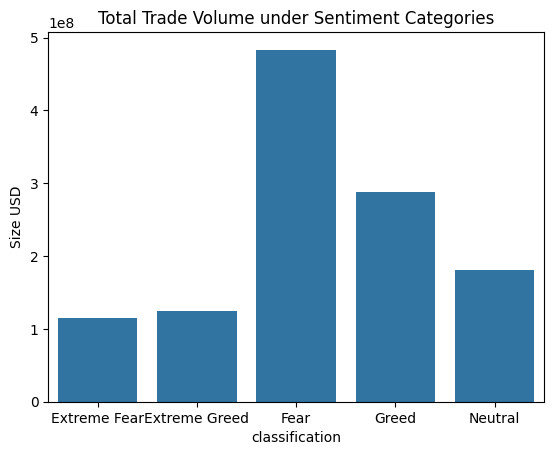

In [17]:
trade_volume = merged.groupby('classification')['Size USD'].sum().reset_index()
print(trade_volume)
sns.barplot(x='classification', y='Size USD', data=trade_volume)
plt.title("Total Trade Volume under Sentiment Categories")
plt.show()


  classification       Win
0   Extreme Fear  0.370607
1  Extreme Greed  0.464943
2           Fear  0.420768
3          Greed  0.384828
4        Neutral  0.396991


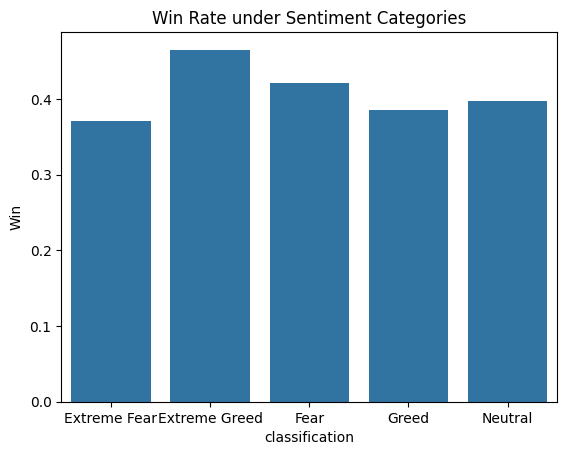

In [18]:
merged['Win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('classification')['Win'].mean().reset_index()
print(win_rate)
sns.barplot(x='classification', y='Win', data=win_rate)
plt.title("Win Rate under Sentiment Categories")
plt.show()


In [ ]:
# Recommendations:
# Traders should adapt strategies based on sentiment signals.
# In Extreme Fear, reduce position sizes and leverage to preserve capital.
# During Greed phases, profits may rise but discipline is key—use moderate leverage and exit early.
# SELL positions often perform better in fearful markets, while BUY positions dominate in greedy ones.
# Monitoring trade volumes can reveal crowd behavior, where contrarian approaches may be safer.
# Overall, integrating sentiment data into trading decisions and reassessing strategies regularly
# ensures resilience against shifting market psychology.